In [4]:
import requests
import pandas as pd

API_KEY = "vYVPfonF7nZQK0oPFQrjW4k3C0uTG5ffWXwRUeJT"

url = "https://api.data.gov/ed/collegescorecard/v1/schools"

params = {
    "api_key": API_KEY,
    "fields": "school.name,school.state,school.city,"
              "latest.admissions.admission_rate.overall,"
              "latest.completion.completion_rate_4yr_150nt,"
              "latest.earnings.10_yrs_after_entry.median,"
              "latest.aid.median_debt.completers.overall,"
              "latest.student.size",
    "per_page": 100,
    "page": 0
}

response = requests.get(url, params=params)
data = response.json()

print(f"Total schools: {data['metadata']['total']}")
print(f"Page size: {len(data['results'])}")

df = pd.DataFrame(data['results'])
print(df.head())
print(df.columns.tolist())

Total schools: 6322
Page size: 100
   latest.admissions.admission_rate.overall  \
0                                    0.5795   
1                                    0.8818   
2                                       NaN   
3                                    0.6857   
4                                    0.9755   

   latest.completion.completion_rate_4yr_150nt  \
0                                       0.2403   
1                                       0.6423   
2                                       1.0000   
3                                       0.6429   
4                                       0.3034   

   latest.earnings.10_yrs_after_entry.median  \
0                                    40628.0   
1                                    54501.0   
2                                    37621.0   
3                                    61767.0   
4                                    34502.0   

   latest.aid.median_debt.completers.overall  latest.student.size  \
0                      

In [7]:
import time

all_results = []
page = 0
per_page = 100
total_pages = (6322 // per_page) + 1

print(f"Pulling {total_pages} pages...")

while page < total_pages:
    params["page"] = page
    params["per_page"] = per_page
    
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f"Error on page {page}: {response.status_code}")
        break
        
    results = response.json().get("results", [])
    
    if not results:
        break
        
    all_results.extend(results)
    
    if page % 10 == 0:
        print(f"Page {page}/{total_pages} — {len(all_results)} schools so far")
    
    page += 1
    time.sleep(0.1)  # be respectful to the API

print(f"\nDone. Total records pulled: {len(all_results)}")
df_full = pd.DataFrame(all_results)
print(df_full.shape)

Pulling 64 pages...
Page 0/64 — 100 schools so far
Page 10/64 — 1100 schools so far
Page 20/64 — 2100 schools so far
Page 30/64 — 3100 schools so far
Page 40/64 — 4100 schools so far
Page 50/64 — 5100 schools so far
Page 60/64 — 6100 schools so far

Done. Total records pulled: 6322
(6322, 8)


In [8]:
# Rename ugly API column names to clean ones
df_clean = df_full.rename(columns={
    "school.name": "school_name",
    "school.state": "state",
    "school.city": "city",
    "latest.admissions.admission_rate.overall": "admission_rate",
    "latest.completion.completion_rate_4yr_150nt": "completion_rate",
    "latest.earnings.10_yrs_after_entry.median": "median_earnings",
    "latest.aid.median_debt.completers.overall": "median_debt",
    "latest.student.size": "student_size"
})

# Check how many schools have complete data
print("Missing values per column:")
print(df_clean.isnull().sum())
print(f"\nShape: {df_clean.shape}")
print(df_clean.head(3)) 

Missing values per column:
admission_rate     4395
completion_rate    4039
median_earnings    1149
median_debt        1507
student_size        735
school_name           0
state                 0
city                  0
dtype: int64

Shape: (6322, 8)
   admission_rate  completion_rate  median_earnings  median_debt  \
0          0.5795           0.2403          40628.0      31000.0   
1          0.8818           0.6423          54501.0      22300.0   
2             NaN           1.0000          37621.0      32189.0   

   student_size                          school_name state        city  
0        6124.0             Alabama A & M University    AL      Normal  
1       11635.0  University of Alabama at Birmingham    AL  Birmingham  
2         241.0                   Amridge University    AL  Montgomery  


In [9]:
# Drop rows missing the two most important columns
df_scored = df_clean.dropna(subset=['median_earnings', 'median_debt'])

# Avoid division by zero
df_scored = df_scored[df_scored['median_debt'] > 0]

# Value score = earnings divided by debt
# Above 1.0 = earning more than you owe → good
# Below 1.0 = earning less than you owe → concerning
df_scored['value_score'] = (
    df_scored['median_earnings'] / df_scored['median_debt']
).round(3)

print(f"Schools with value scores: {len(df_scored)}")
print(f"\nValue score distribution:")
print(df_scored['value_score'].describe())

print(f"\nBottom 10 worst value schools:")
print(df_scored.nsmallest(10, 'value_score')[
    ['school_name', 'state', 'median_earnings', 
     'median_debt', 'value_score']
])

Schools with value scores: 4500

Value score distribution:
count    4500.000000
mean        3.216990
std         1.456171
min         0.537000
25%         2.194000
50%         2.948500
75%         3.881500
max        14.316000
Name: value_score, dtype: float64

Bottom 10 worst value schools:
                           school_name state  median_earnings  median_debt  \
993                  Martin University    IN          22544.0      42002.0   
4666     Washington Barber College Inc    AR           8579.0      14000.0   
3608           Dorsey School of Beauty    MI          13256.0      16500.0   
3192         Eagle Gate College-Murray    UT          37518.0      43021.0   
4377         Eagle Gate College-Layton    UT          37518.0      43021.0   
5650   Eagle Gate College-Boise Campus    ID          37518.0      43021.0   
2840                  Allen University    SC          30497.0      34290.0   
3768                     Provo College    UT          39645.0      41733.0   
5649 

In [10]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///college_debt.db")
df_scored.to_sql("colleges", engine, if_exists="replace", index=False)

print("Saved to college_debt.db")
print(f"Rows in database: {len(df_scored)}")

Saved to college_debt.db
Rows in database: 4500


## Finding 1 — Worst Value Schools
Provo College (UT and ID campuses) and Laurus College (CA) have the lowest 
value scores in the dataset — median earnings barely exceed or fall below 
median debt at graduation.

Students at these institutions are paying more for their degree than 
it returns in earnings within 10 years. This is the definition of 
a predatory outcome, regardless of intent.

Value Score = Median Earnings / Median Debt
Below 1.0 = graduates earn less than they borrowed

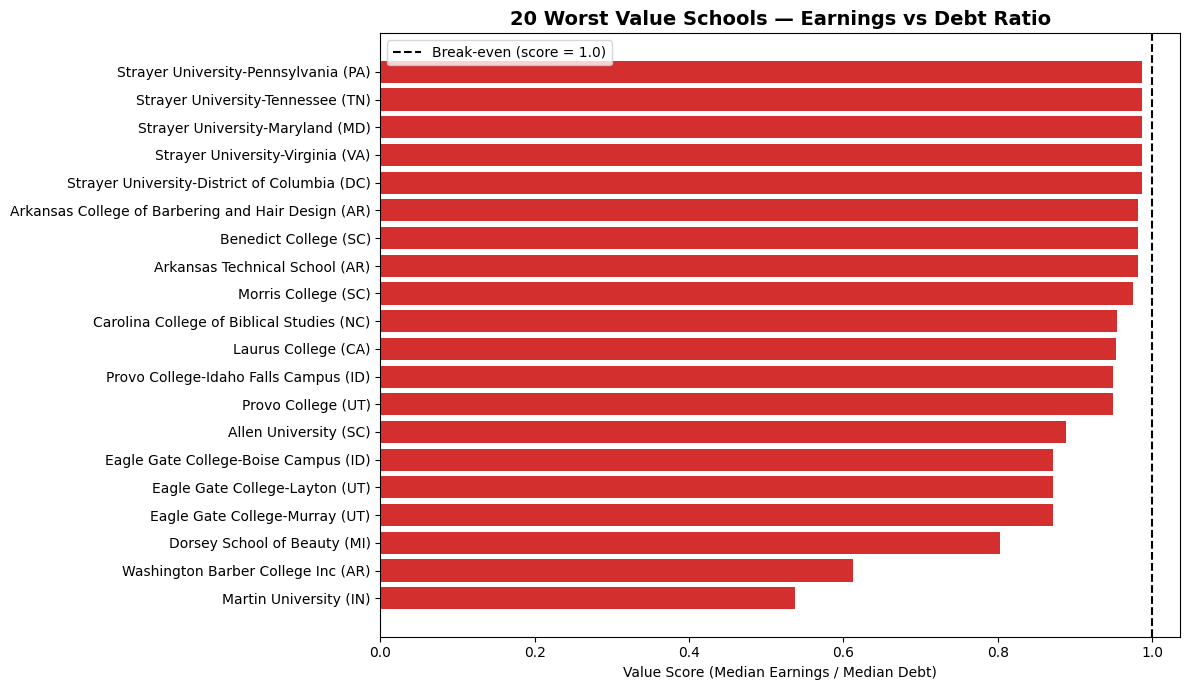

In [ ]:
# Bottom 20 worst value schools
import matplotlib.pyplot as plt
bottom_20 = df_scored.nsmallest(20, 'value_score')[
    ['school_name', 'state', 'value_score']
]

plt.figure(figsize=(12, 7))
colors = ['#d32f2f' if v < 1.0 else '#f57c00' 
          for v in bottom_20['value_score']]

plt.barh(bottom_20['school_name'] + ' (' + bottom_20['state'] + ')', 
         bottom_20['value_score'], color=colors)

plt.axvline(x=1.0, color='black', linestyle='--', 
            linewidth=1.5, label='Break-even (score = 1.0)')
plt.title('20 Worst Value Schools — Earnings vs Debt Ratio', 
          fontsize=14, fontweight='bold')
plt.xlabel('Value Score (Median Earnings / Median Debt)')
plt.legend()
plt.tight_layout()
plt.show()



In [13]:
# Top 20 best value schools  
top_20 = df_scored.nlargest(20, 'value_score')[
    ['school_name', 'state', 'median_earnings', 
     'median_debt', 'value_score']
]
print(top_20)

                                            school_name state  \
4123         New Community Career & Technical Institute    NJ   
1842                Adult and Continuing Education-BCTS    NJ   
305                                     Reedley College    CA   
328   Los Angeles County College of Nursing and Alli...    CA   
1147                                      Berea College    KY   
3081                                     Laredo College    TX   
2401             Hobart Institute of Welding Technology    OH   
1881                               Princeton University    NJ   
1915                      New Mexico Military Institute    NM   
871                                   Kaskaskia College    IL   
3535                                Stanford University    CA   
2178              United States Merchant Marine Academy    NY   
759                          Savannah Technical College    GA   
3012                            Alvin Community College    TX   
259                      

## Finding 2 — The Break-Even Line
Only 20 schools (0.5% of scored institutions) fall below a value score 
of 1.0 — meaning graduates earn less than they borrowed within 10 years.

However, these 20 schools represent a concentrated pattern of poor outcomes 
worth investigating at the policy level.

Notable: The top 2 highest value schools in the entire dataset are both 
located in New Jersey — New Community Career & Technical Institute and 
Adult and Continuing Education-BCTS.

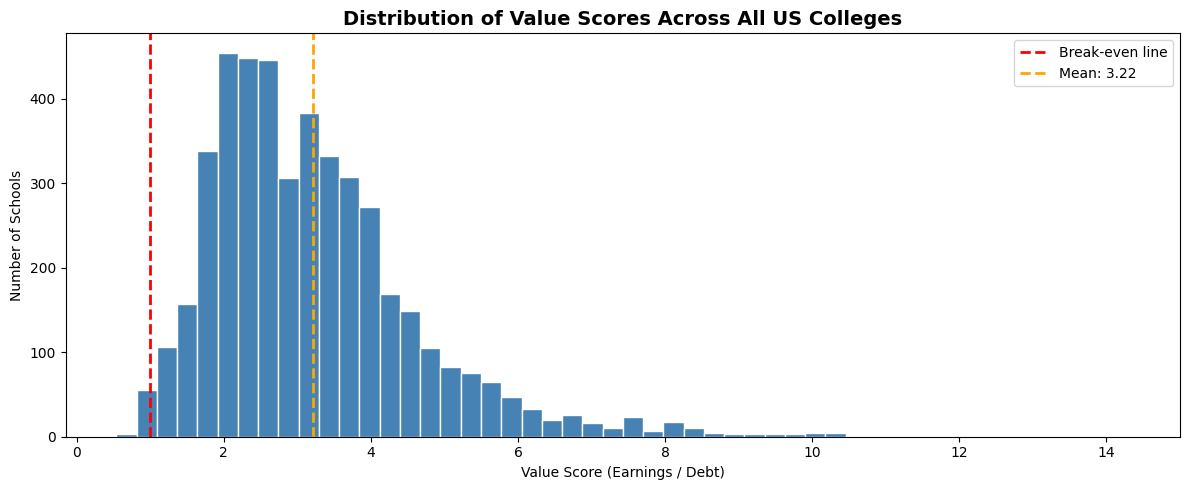

In [14]:
# Distribution of value scores — where does the bulk sit?
plt.figure(figsize=(12, 5))
plt.hist(df_scored['value_score'], bins=50, 
         color='steelblue', edgecolor='white')
plt.axvline(x=1.0, color='red', linestyle='--', 
            linewidth=2, label='Break-even line')
plt.axvline(x=df_scored['value_score'].mean(), 
            color='orange', linestyle='--',
            linewidth=2, label=f"Mean: {df_scored['value_score'].mean():.2f}")
plt.title('Distribution of Value Scores Across All US Colleges', 
          fontsize=14, fontweight='bold')
plt.xlabel('Value Score (Earnings / Debt)')
plt.ylabel('Number of Schools')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Which states have the best and worst average value scores?
state_scores = df_scored.groupby('state')['value_score'].agg(
    ['mean', 'count', 'min']
).round(3).sort_values('mean', ascending=False)

state_scores.columns = ['avg_value_score', 'num_schools', 'worst_score']

print("Top 10 best value states:")
print(state_scores.head(10))

print("\nBottom 10 worst value states:")
print(state_scores.tail(10))

Top 10 best value states:
       avg_value_score  num_schools  worst_score
state                                           
WY               4.490           10        3.160
CA               4.025          409        0.953
NV               3.952           32        1.530
AZ               3.820           88        1.166
IL               3.685          179        1.110
NJ               3.644           99        0.987
PR               3.602           79        1.607
NY               3.584          261        0.996
HI               3.554           16        1.196
WA               3.543           85        1.014

Bottom 10 worst value states:
       avg_value_score  num_schools  worst_score
state                                           
LA               2.721           82        1.098
GA               2.718          129        0.987
SD               2.717           18        1.286
SC               2.694           78        0.889
VT               2.688           10        1.329
WV          

Correlation between school size and value score: 0.092


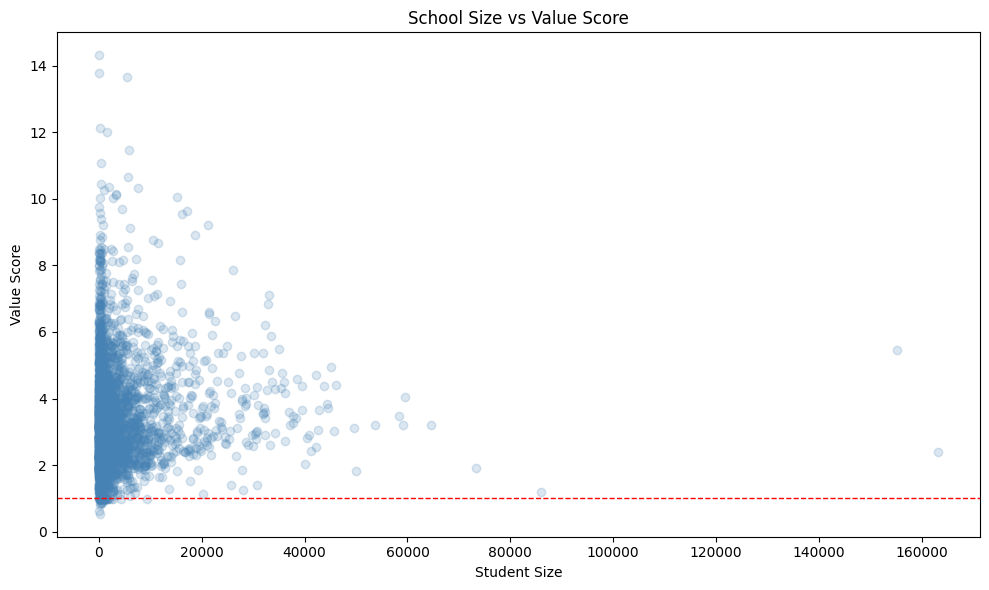

In [16]:
# Do larger schools provide better value?
df_sized = df_scored.dropna(subset=['student_size'])

correlation = df_sized['student_size'].corr(df_sized['value_score'])
print(f"Correlation between school size and value score: {correlation:.3f}")

plt.figure(figsize=(10, 6))
plt.scatter(df_sized['student_size'], df_sized['value_score'], 
            alpha=0.2, color='steelblue')
plt.title('School Size vs Value Score')
plt.xlabel('Student Size')
plt.ylabel('Value Score')
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## Finding 3 — National Picture
The mean value score across 3,768 scored institutions is 3.22 — 
meaning the average graduate earns 3x their debt within 10 years.
The problem is concentrated, not systemic. The 20 schools below 
break-even represent outliers, not the norm.

## Finding 4 — School Size Doesn't Matter
Correlation between enrollment size and value score: 0.092 — 
essentially zero. Bigger schools are not safer bets than smaller ones.
Students cannot use school size as a proxy for financial outcome quality.